In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
clothes = pd.read_csv('/content/drive/MyDrive/kaggle/Clothing Sales Data New.csv')
clothes.head()

,saleID,saleDate,productID,productName,productCategory,productColor,productSize,quantity,unitPrice,costPrice,...,totalCost,customerID,customerName,location,locationLatitude,locationLongitude,salespersonID,salespersonName,status,salesChannel
0,S00001,2023-09-01 21:43:00,P1000,Women's_000,Women's Dresses,Red,XXL,2,1572.76,1154.01,...,2308.02,C20000,Vishal_0000,Tiruchirappalli,10.7905,78.7047,SP114,Salesperson_14,Pending,online
1,S00002,2023-03-06 15:20:00,P1001,Women's_001,Women's Dresses,Maroon,XS,1,247.34,220.37,...,220.37,C20001,Sathish_0001,Erode,11.3400,77.7172,SP102,Salesperson_2,Paid,online
2,S00003,2024-06-25 12:10:00,P1002,Women's_002,Women's Dresses,Black,S,2,1620.21,1269.43,...,2538.86,C20002,Anu_0002,Chennai,13.0827,80.2707,SP135,Salesperson_35,Pending,in-store
3,S00004,2023-01-05 10:31:00,P1003,Kurta_003,Kurta,Black,L,4,520.84,358.15,...,1432.60,C20003,Sathish_0003,Salem,11.6643,78.1460,SP100,Salesperson_0,Pending,in-store
4,S00005,2023-08-27 15:47:00,P1004,Kurta_004,Kurta,Yellow,M,1,1079.66,966.26,...,966.26,C20004,Kavin_0004,Tiruchirappalli,10.7905,78.7047,SP148,Salesperson_48,Returned,in-store


In [4]:
print("Ukuran data:", clothes.shape)
print("\nTipe kolom:")
print(clothes.dtypes)

Ukuran data: (10000, 21)

Tipe kolom:
saleID                object
saleDate              object
productID             object
productName           object
productCategory       object
productColor          object
productSize           object
quantity               int64
unitPrice            float64
costPrice            float64
totalAmount          float64
totalCost            float64
customerID            object
customerName          object
location              object
locationLatitude     float64
locationLongitude    float64
salespersonID         object
salespersonName       object
status                object
salesChannel          object
dtype: object


In [5]:
print("Missing values per kolom:")
print(clothes.isnull().sum())

print("\nJumlah duplikat:", clothes.duplicated().sum())

print("\nNilai unik kolom status:")
print(clothes['status'].value_counts())

Missing values per kolom:
saleID               0
saleDate             0
productID            0
productName          0
productCategory      0
productColor         0
productSize          0
quantity             0
unitPrice            0
costPrice            0
totalAmount          0
totalCost            0
customerID           0
customerName         0
location             0
locationLatitude     0
locationLongitude    0
salespersonID        0
salespersonName      0
status               0
salesChannel         0
dtype: int64

Jumlah duplikat: 0

Nilai unik kolom status:
status
Shipped      2062
Cancelled    2015
Pending      2010
Paid         1962
Returned     1951
Name: count, dtype: int64


In [6]:
# Parse tanggal
clothes['saleDate'] = pd.to_datetime(clothes['saleDate'])

# Buat kolom turunan
clothes['month']      = clothes['saleDate'].dt.to_period('M')
clothes['month_name'] = clothes['saleDate'].dt.strftime('%b %Y')
clothes['year']       = clothes['saleDate'].dt.year
clothes['day_name']   = clothes['saleDate'].dt.day_name()
clothes['profit']     = clothes['totalAmount'] - clothes['totalCost']
clothes['margin_pct'] = (clothes['profit'] / clothes['totalAmount']) * 100

# Filter hanya transaksi sukses untuk analisis revenue
clothes_success = clothes[clothes['status'].isin(['Shipped', 'Paid'])].copy()

# Konfirmasi
print(clothes_success['status'].value_counts())
print("Total transaksi sukses:", len(clothes_success))


status
Shipped    2062
Paid       1962
Name: count, dtype: int64
Total transaksi sukses: 4024


Untuk memulai analisis, terlebih dahulu dilakukan *project background* dengan melihat *line chart* *total amount* dan *total customer* guna mengetahui hal-hal apa saja yang dapat dianalisis hingga menemukan *insight* yang dapat membangun bisnis.

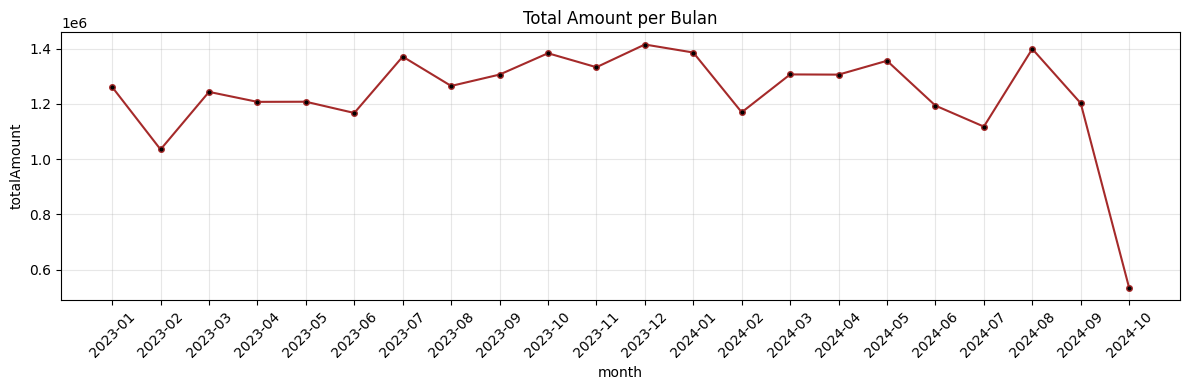

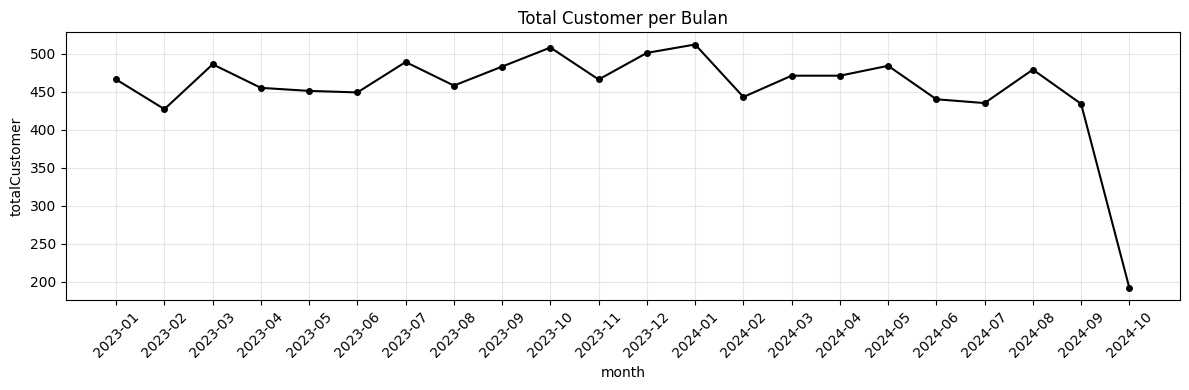

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# PLOT 1 — Revenue per bulan
data_plot = (clothes
    .groupby('month')
    .agg(totalAmount = ('totalAmount', 'sum'))
    .reset_index()
)
data_plot['month'] = data_plot['month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(data_plot['month'], data_plot['totalAmount'],
         color='brown', linewidth=1.5, marker='o',
         markersize=4, markerfacecolor='black')
plt.title('Total Amount per Bulan')
plt.xlabel('month')
plt.ylabel('totalAmount')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PLOT 2 — Customer per bulan
customer_month = (clothes
    .groupby('month')
    .agg(totalCustomer = ('customerID', 'nunique'))
    .reset_index()
)
customer_month['month'] = customer_month['month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(customer_month['month'], customer_month['totalCustomer'],
         color='black', linewidth=1.5, marker='o',
         markersize=4, markerfacecolor='black')
plt.title('Total Customer per Bulan')
plt.xlabel('month')
plt.ylabel('totalCustomer')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dapat dilihat bahwa di bulan Oktober tahun 2024, pada kedua plot sangat menukik tajam, hal ini perlu dipertanyakan. Maka dari itu langkah selanjutnya yaitu cek berapa jumlah *total amount* dan *total customer* per bulannya.

In [8]:
# Lihat dulu bulan apa aja yang ada di data
print(clothes['month'].value_counts().sort_index())

month
2023-01    466
2023-02    427
2023-03    486
2023-04    455
2023-05    451
2023-06    449
2023-07    489
2023-08    458
2023-09    483
2023-10    508
2023-11    466
2023-12    501
2024-01    512
2024-02    443
2024-03    471
2024-04    471
2024-05    484
2024-06    440
2024-07    435
2024-08    479
2024-09    434
2024-10    192
Freq: M, Name: count, dtype: int64


Setalah didapatkan informasi, ternyata memang di bulan oktober tahun 2024 tersebut memiliki jumlah *total amount* dan *customer* yang sangat sedikit jika dibandingkan dengan bulan lainnya. Kemudian langkah selanjutya dapat dilihat berapa hari total transaksi yang dilakukan pada bulan tersebut.

In [9]:
oktober = clothes[
    (clothes['saleDate'].dt.month == 10) &
    (clothes['saleDate'].dt.year == 2024)
]
print(oktober['saleDate'].dt.day.value_counts().sort_index())

saleDate
1     23
2     15
3     18
4     16
5     12
6     16
7     19
8     16
9     19
10    19
11    19
Name: count, dtype: int64


Ternyata hanya ada 11 hari transaksi pada bulan Oktober tahun 2024, maka bulan tersebut dapat dihapus dalam analisis.

In [10]:
# Hapus baris yang bulan Oktober 2024
df = clothes[clothes['month'] != '2024-10']
df_success = clothes_success[clothes['month'] != '2024-10'].copy()

# Konfirmasi sudah terhapus
print(df['month'].value_counts().sort_index())

month
2023-01    466
2023-02    427
2023-03    486
2023-04    455
2023-05    451
2023-06    449
2023-07    489
2023-08    458
2023-09    483
2023-10    508
2023-11    466
2023-12    501
2024-01    512
2024-02    443
2024-03    471
2024-04    471
2024-05    484
2024-06    440
2024-07    435
2024-08    479
2024-09    434
Freq: M, Name: count, dtype: int64


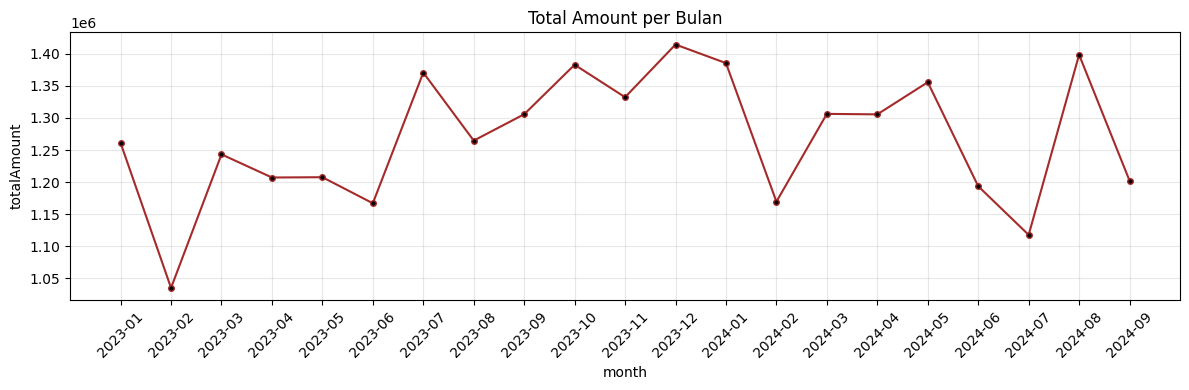

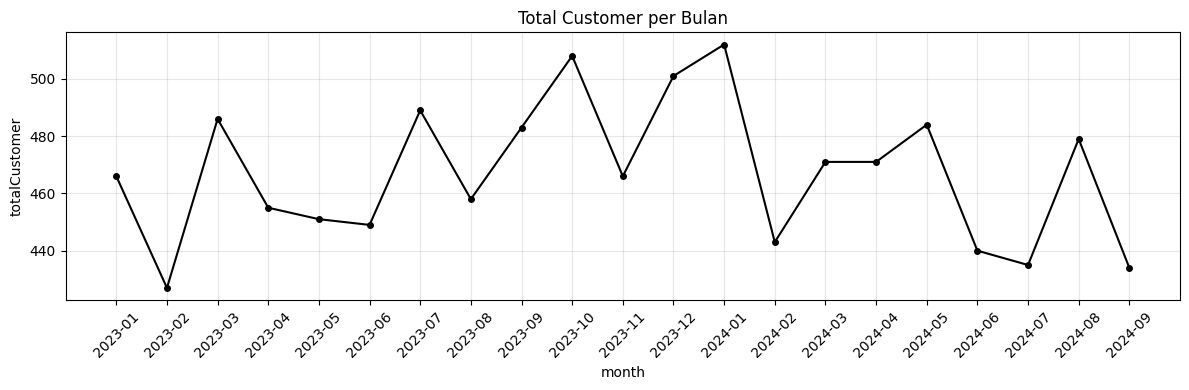

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

###plot 1 revenue per bulan
data_plot = (df
    .groupby('month')
    .agg(totalAmount = ('totalAmount', 'sum'))
    .reset_index()
)
data_plot['month'] = data_plot['month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(data_plot['month'], data_plot['totalAmount'],
         color='brown', linewidth=1.5, marker='o',
         markersize=4, markerfacecolor='black')
plt.title('Total Amount per Bulan')
plt.xlabel('month')
plt.ylabel('totalAmount')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# PLOT 2 — Customer per bulan
customer_month = (df
    .groupby('month')
    .agg(totalCustomer = ('customerID', 'nunique'))
    .reset_index()
)
customer_month['month'] = customer_month['month'].astype(str)

plt.figure(figsize=(12, 4))
plt.plot(customer_month['month'], customer_month['totalCustomer'],
         color='black', linewidth=1.5, marker='o',
         markersize=4, markerfacecolor='black')
plt.title('Total Customer per Bulan')
plt.xlabel('month')
plt.ylabel('totalCustomer')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observasi Plot:**  
1. Plot *Revenue* (*Total Amount* per bulan) --> Menunjukkan fluktuasi bulanan yang cukup tajam, serta ada lonjakan di tengah 2023 dan awal 2024 yang bisa mengindikasikan *seasonal demand* (misalnya Lebaran, *back-to-school*, atau *year-end sale*). Tren umumnya ke atas, tapi dengan volatilitas tinggi sekitar kurang lebih 25%.
2. Plot *Total Customer* --> Bergerak dalam *range* yang relatif sempit (430–515), tapi polanya tidak selalu searah dengan *revenue*. *Revenue* bisa naik bukan karena lebih banyak *customer*, melainkan karena tiap *customer* belanja lebih banyak (AOV meningkat).

Dari plot tersebut maka didapatkan beberapa bussiness problem dengan beberapa pertanyaan sebagai berikut:  
1. *Revenue* dan jumlah customer paling tinggi dan paling rendah terjadi di bulan apa?
2. *Platform* penjualan mana yang paling menghasilkan *revenue* dan *profit*?
3. Berapa banyak produk yang menghasilkan 80% *revenue*?
4. Customer mana yang berpotensi untuk dipertahankan dan mana yang sudah lama tidak bertransaksi?
5. Berapa banyak transaksi yg gagal atau dibatalkan?

---
---

**1. Revenue & customer paling tinggi/rendah di bulan apa?**  
Perlu tau supaya bisa siapkan stok lebih banyak, dan untuk penjualan yang sedikit di bulan tertentu agar diadakan promo untuk mendorong penjualan.

In [12]:
monthly = df_success.groupby('month').agg(
    revenue   = ('totalAmount', 'sum'),
    customers = ('customerID',  'nunique'),
    orders    = ('saleID',      'count'),
    profit    = ('profit',      'sum')
).reset_index()

monthly['month_str'] = monthly['month'].astype(str)
monthly['aov'] = monthly['revenue'] / monthly['orders']

print(monthly.to_string())

      month    revenue  customers  orders     profit month_str          aov
0   2023-01  476934.68        175     175  125176.66   2023-01  2725.341029
1   2023-02  406967.00        165     165   96421.80   2023-02  2466.466667
2   2023-03  510576.94        200     200  126395.84   2023-03  2552.884700
3   2023-04  509665.75        189     189  120407.47   2023-04  2696.644180
4   2023-05  469470.93        184     184  119553.61   2023-05  2551.472446
5   2023-06  449590.07        189     189  111892.22   2023-06  2378.783439
6   2023-07  563860.79        204     204  135735.94   2023-07  2764.023480
7   2023-08  566105.42        207     207  134445.77   2023-08  2734.808792
8   2023-09  504836.82        188     188  127926.23   2023-09  2685.302234
9   2023-10  575753.70        213     213  139253.67   2023-10  2703.069014
10  2023-11  489783.63        182     182  123494.52   2023-11  2691.118846
11  2023-12  542083.01        187     187  139671.74   2023-12  2898.839626
12  2024-01 

In [13]:
monthly['revenue_ma3']   = monthly['revenue'].rolling(window=3).mean()
monthly['customers_ma3'] = monthly['customers'].rolling(window=3).mean()

print(monthly[['month_str','revenue','revenue_ma3']].to_string())

   month_str    revenue    revenue_ma3
0    2023-01  476934.68            NaN
1    2023-02  406967.00            NaN
2    2023-03  510576.94  464826.206667
3    2023-04  509665.75  475736.563333
4    2023-05  469470.93  496571.206667
5    2023-06  449590.07  476242.250000
6    2023-07  563860.79  494307.263333
7    2023-08  566105.42  526518.760000
8    2023-09  504836.82  544934.343333
9    2023-10  575753.70  548898.646667
10   2023-11  489783.63  523458.050000
11   2023-12  542083.01  535873.446667
12   2024-01  605810.86  545892.500000
13   2024-02  426909.78  524934.550000
14   2024-03  536430.58  523050.406667
15   2024-04  497014.66  486785.006667
16   2024-05  575435.56  536293.600000
17   2024-06  499048.71  523832.976667
18   2024-07  391014.76  488499.676667
19   2024-08  486962.92  459008.796667
20   2024-09  434228.27  437401.983333


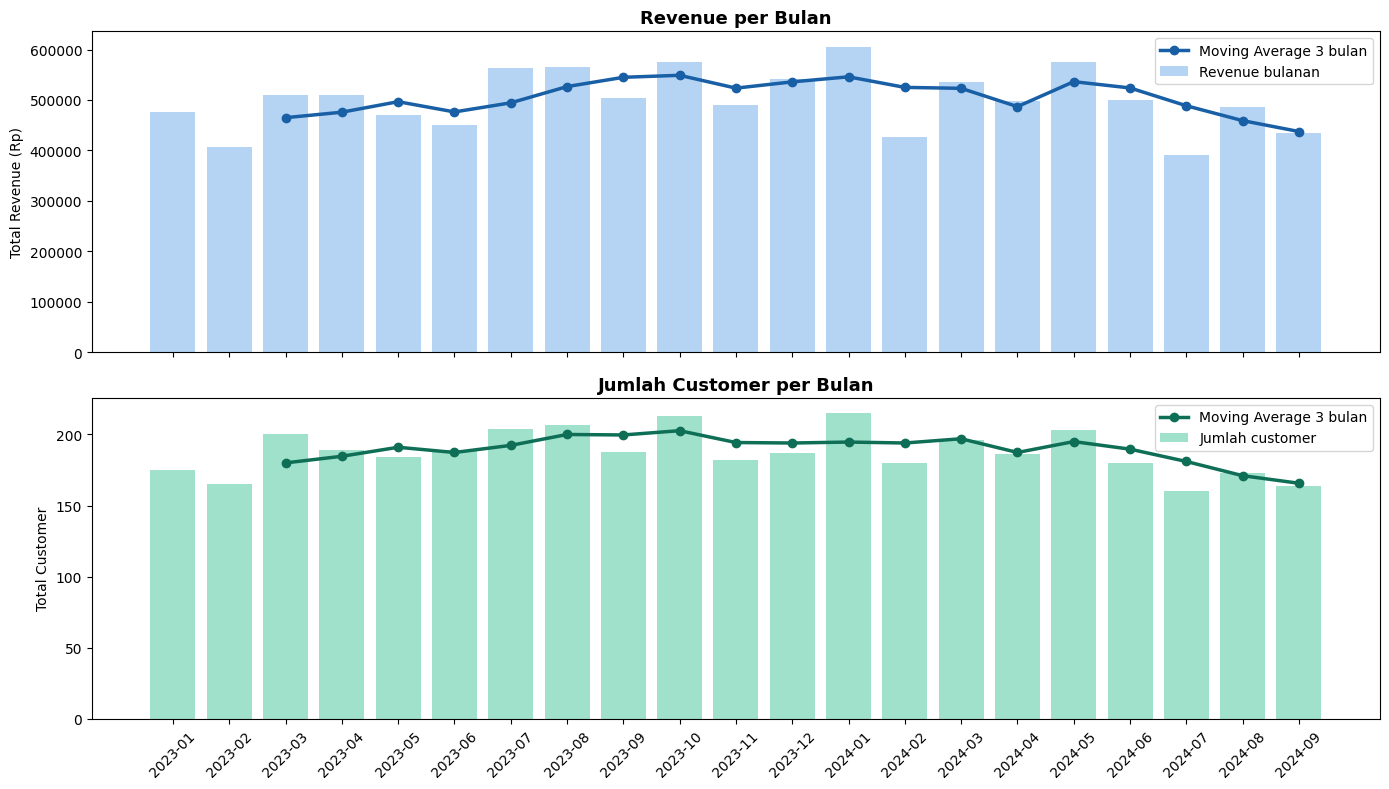

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot revenue
ax1.bar(monthly['month_str'], monthly['revenue'],
        color='#B5D4F4', label='Revenue bulanan')
ax1.plot(monthly['month_str'], monthly['revenue_ma3'],
         color='#185FA5', linewidth=2.5, marker='o',
         label='Moving Average 3 bulan')
ax1.set_title('Revenue per Bulan', fontsize=13, fontweight='bold')
ax1.set_ylabel('Total Revenue (Rp)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# Plot customer
ax2.bar(monthly['month_str'], monthly['customers'],
        color='#9FE1CB', label='Jumlah customer')
ax2.plot(monthly['month_str'], monthly['customers_ma3'],
         color='#0F6E56', linewidth=2.5, marker='o',
         label='Moving Average 3 bulan')
ax2.set_title('Jumlah Customer per Bulan', fontsize=13, fontweight='bold')
ax2.set_ylabel('Total Customer')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('tren_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
best_rev  = monthly.loc[monthly['revenue'].idxmax()]
worst_rev = monthly.loc[monthly['revenue'].idxmin()]
best_cust  = monthly.loc[monthly['customers'].idxmax()]
worst_cust = monthly.loc[monthly['customers'].idxmin()]

print("=== REVENUE ===")
print(f"Tertinggi : {best_rev['month_str']} → Rp {best_rev['revenue']:,.0f}")
print(f"Terendah  : {worst_rev['month_str']} → Rp {worst_rev['revenue']:,.0f}")
print("\n=== CUSTOMER ===")
print(f"Terbanyak : {best_cust['month_str']} → {best_cust['customers']:.0f} customer")
print(f"Tersedikit: {worst_cust['month_str']} → {worst_cust['customers']:.0f} customer")

=== REVENUE ===
Tertinggi : 2024-01 → Rp 605,811
Terendah  : 2024-07 → Rp 391,015

=== CUSTOMER ===
Terbanyak : 2024-01 → 215 customer
Tersedikit: 2024-07 → 160 customer


**Insight:**  
Revenue dan customer tertinggi sama-sama terjadi di Januari 2024, artinya revenue naik memang karena lebih banyak orang yang beli, bukan karena orang belanja lebih mahal.  
**Rekomendasi:**  
Persiapkan stok lebih banyak menjelang bulan Januari dan buat promo khusus atau flash sale pada bulan yang cenderung sepi.

---
---

**2. Platform mana yang paling menghasilkan revenue dan profit?**  
Perlu lihat dua dimensi sekaligus (revenue dan profit). Channel dengan revenue tinggi bisa saja margin-nya kecil.

In [16]:
channel = df_success.groupby('salesChannel').agg(
    revenue    = ('totalAmount', 'sum'),
    cost       = ('totalCost',   'sum'),
    profit     = ('profit',      'sum'),
    orders     = ('saleID',      'count'),
    customers  = ('customerID',  'nunique')
).reset_index()

channel['margin_pct'] = (channel['profit'] / channel['revenue']) * 100
channel['aov']        = channel['revenue'] / channel['orders']

print(channel.round(2).to_string())

  salesChannel     revenue        cost      profit  orders  customers  margin_pct      aov
0     in-store  5409495.64  4061201.20  1348294.44    2000       2000       24.92  2704.75
1   mobile_app  1451717.05  1100702.52   351014.53     576        576       24.18  2520.34
2       online  3104167.71  2335125.70   769042.01    1155       1155       24.77  2687.59
3  third-party   553104.44   409727.52   143376.92     209        209       25.92  2646.43


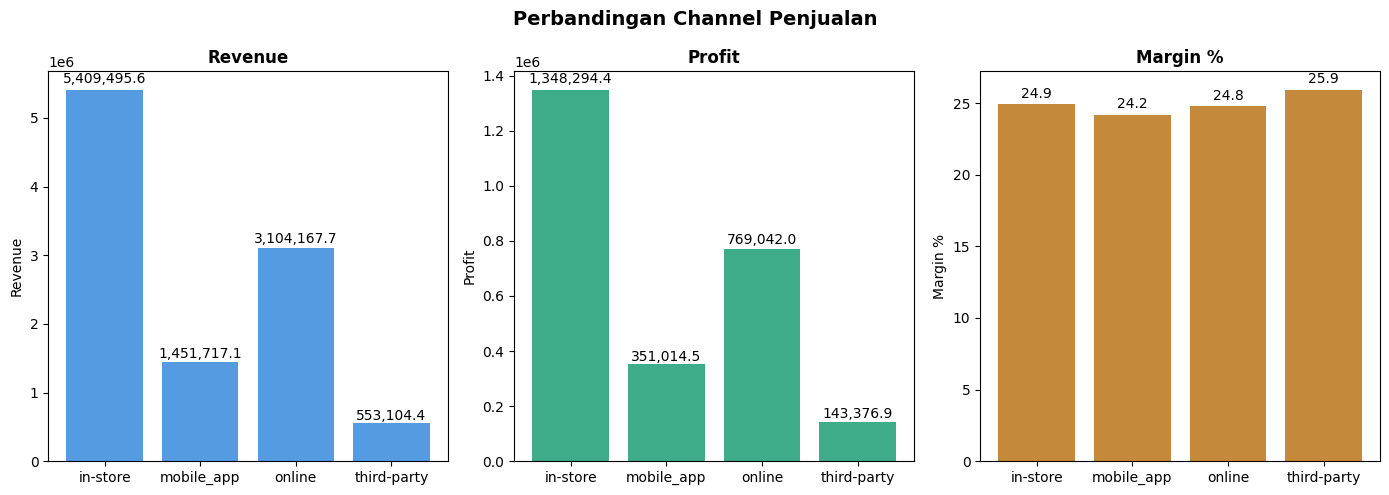

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [('revenue','Revenue',  '#378ADD'),
           ('profit', 'Profit',   '#1D9E75'),
           ('margin_pct','Margin %','#BA7517')]

for ax, (col, label, color) in zip(axes, metrics):
    bars = ax.bar(channel['salesChannel'], channel[col], color=color, alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, channel[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bar.get_height()*0.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Channel Penjualan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('channel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
best_rev    = channel.loc[channel['revenue'].idxmax(), 'salesChannel']
best_profit = channel.loc[channel['profit'].idxmax(),  'salesChannel']
best_margin = channel.loc[channel['margin_pct'].idxmax(), 'salesChannel']

print(f"Channel revenue terbesar : {best_rev}")
print(f"Channel profit terbesar  : {best_profit}")
print(f"Channel margin tertinggi : {best_margin}")

if best_rev != best_profit:
    print("\nCatatan: Channel dengan revenue terbesar BUKAN yang paling profitable!")
    print("Ini sinyal perlu evaluasi efisiensi biaya per channel.")

Channel revenue terbesar : in-store
Channel profit terbesar  : in-store
Channel margin tertinggi : third-party


**Insight:**
- In-store jauh memimpin di revenue (5,4jt) dan profit (1,3jt) dibanding channel lain. Artinya penjualan tatap muka masih jadi tulang punggung bisnis ini.  
- Third-party punya margin tertinggi (25.9%) tapi revenue dan profitnya paling kecil karena volume transaksinya sedikit. Artinya channel ini efisien tapi belum dimanfaatkan maksimal.  
- Keempat channel punya margin yang hampir sama berkisar antara 24.2% sampai 25.9%. Bedanya hanya 1-2%, artinya struktur biaya semua channel relatif sama efisiennya.
- di era digital sekarang, belanja online sedang marak-maraknya, tetapi platform mobile app dan online masih dibawah in store.  

**Rekomendasi:**  
- Pertahankan dan perkuat operasional in store, pastikan stok selalu tersedia, display produk menarik, dan customer service di toko prima.
- Tingkatkan volume penjualan di third-party karena margin-nya paling tinggi, kalau volumenya naik profitnya bisa sangat signifikan.
- Karena margin tidak terlalu berbeda, keputusan fokus channel sebaiknya berdasarkan potensi volume bukan efisiensi biaya.
- Ada peluang besar untuk tumbuh di online dan mobile app, bisa dengan iklan digital, promo khusus aplikasi, atau gratis ongkir untuk mendorong transaksi di kedua channel ini.


---
---

**3. Berapa banyak produk yang dibutuhkan untuk mencapai 80% total revenue, dan produk mana saja yang termasuk di dalamnya?**  
Pareto Analysis (ABC Classification), Pareto adalah cara paling efisien untuk prioritisasi. Daripada analisis semua produk satu-satu, langsung ketahuan mana yang worth difokuskan.

In [19]:
product = df_success.groupby('productName').agg(
    revenue = ('totalAmount', 'sum'),
    profit  = ('profit',      'sum'),
    orders  = ('saleID',      'count')
).sort_values('revenue', ascending=False).reset_index()

product['cum_revenue'] = product['revenue'].cumsum()
product['cum_pct']     = product['cum_revenue'] / product['revenue'].sum() * 100
product['ABC'] = pd.cut(product['cum_pct'],
                        bins=[0, 80, 95, 100],
                        labels=['A', 'B', 'C'])

print("=== PRODUK KATEGORI A (top 80% revenue) ===")
print(product[product['ABC']=='A'][['productName','revenue','cum_pct']].to_string())

=== PRODUK KATEGORI A (top 80% revenue) ===
         productName   revenue    cum_pct
0          Men's_228  21389.15   0.203348
1          Kurta_352  19989.64   0.393391
2          Kurta_304  18932.16   0.573381
3          Men's_457  18731.75   0.751465
4        Women's_301  18552.47   0.927844
5        Women's_080  18307.64   1.101896
6          Jeans_206  18219.58   1.275111
7          Kid's_280  17774.49   1.444095
8          Jeans_074  17422.15   1.609728
9     Sportswear_456  16958.56   1.770955
10        Sarees_196  16829.78   1.930957
11       Women's_236  16616.19   2.088928
12      T-Shirts_266  16468.64   2.245496
13         Kurta_238  16399.49   2.401408
14         Kid's_109  16075.02   2.554234
15         Jeans_122  15967.72   2.706040
16      T-Shirts_399  15644.30   2.854772
17         Kurta_162  15560.52   3.002707
18       Women's_117  15431.05   3.149411
19        Sarees_135  15236.48   3.294265
20         Kurta_272  15127.64   3.438085
21        Sarees_435  14989.50  

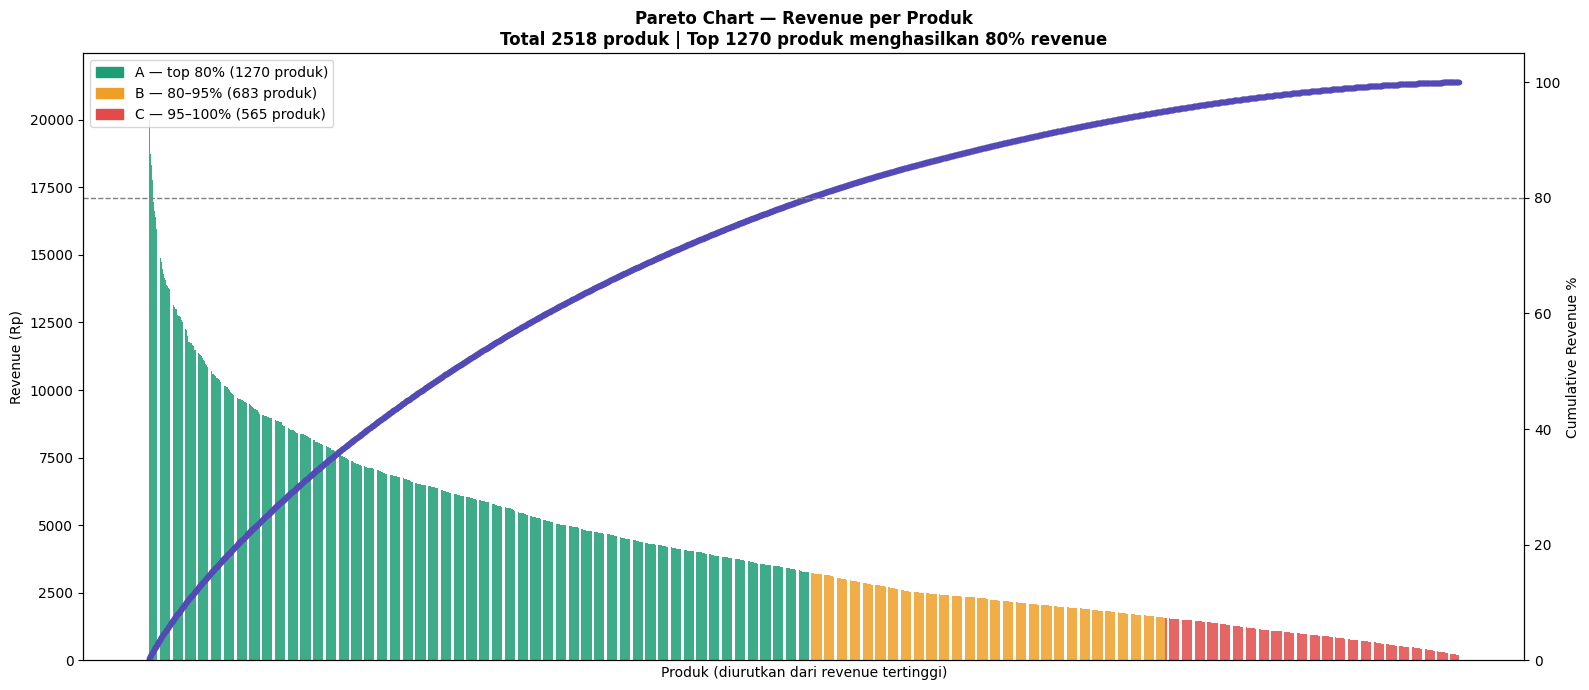


=== TOP 20 PRODUK (Kategori A) ===
   productName  revenue  cum_pct ABC
     Men's_228 21389.15 0.203348   A
     Kurta_352 19989.64 0.393391   A
     Kurta_304 18932.16 0.573381   A
     Men's_457 18731.75 0.751465   A
   Women's_301 18552.47 0.927844   A
   Women's_080 18307.64 1.101896   A
     Jeans_206 18219.58 1.275111   A
     Kid's_280 17774.49 1.444095   A
     Jeans_074 17422.15 1.609728   A
Sportswear_456 16958.56 1.770955   A
    Sarees_196 16829.78 1.930957   A
   Women's_236 16616.19 2.088928   A
  T-Shirts_266 16468.64 2.245496   A
     Kurta_238 16399.49 2.401408   A
     Kid's_109 16075.02 2.554234   A
     Jeans_122 15967.72 2.706040   A
  T-Shirts_399 15644.30 2.854772   A
     Kurta_162 15560.52 3.002707   A
   Women's_117 15431.05 3.149411   A
    Sarees_135 15236.48 3.294265   A


In [20]:
fig, ax1 = plt.subplots(figsize=(16, 7))

colors = product['ABC'].map({'A':'#1D9E75','B':'#EF9F27','C':'#E24B4A'})
ax1.bar(range(len(product)), product['revenue'],
        color=colors, alpha=0.85)

ax1.set_ylabel('Revenue (Rp)')
ax1.set_xlabel('Produk (diurutkan dari revenue tertinggi)')

# HAPUS label x — ganti keterangan di judul saja
ax1.set_xticks([])

ax2 = ax1.twinx()
ax2.plot(range(len(product)), product['cum_pct'],
         color='#534AB7', linewidth=2, marker='o', markersize=3)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
ax2.set_ylabel('Cumulative Revenue %')
ax2.set_ylim(0, 105)

from matplotlib.patches import Patch
legend = [Patch(color='#1D9E75', label=f"A — top 80% ({len(product[product['ABC']=='A'])} produk)"),
          Patch(color='#EF9F27', label=f"B — 80–95% ({len(product[product['ABC']=='B'])} produk)"),
          Patch(color='#E24B4a', label=f"C — 95–100% ({len(product[product['ABC']=='C'])} produk)")]
ax1.legend(handles=legend, loc='upper left')

plt.title('Pareto Chart — Revenue per Produk\n'
          f'Total {len(product)} produk | '
          f"Top {len(product[product['ABC']=='A'])} produk menghasilkan 80% revenue",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pareto_produk.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabel top 20 produk dicetak di bawah sebagai pengganti label
print("\n=== TOP 20 PRODUK (Kategori A) ===")
print(product[['productName','revenue','cum_pct','ABC']].head(20).to_string(index=False))

In [21]:
summary = product.groupby('ABC').agg(
    jumlah_produk = ('productName', 'count'),
    total_revenue = ('revenue', 'sum')
).reset_index()
summary['pct_produk']  = summary['jumlah_produk'] / len(product) * 100
summary['pct_revenue'] = summary['total_revenue'] / product['revenue'].sum() * 100

print(summary.round(1).to_string())

  ABC  jumlah_produk  total_revenue  pct_produk  pct_revenue
0   A           1270      8414584.8        50.4         80.0
1   B            683      1576803.7        27.1         15.0
2   C            565       527096.3        22.4          5.0


**Insight:**  
Berbeda dari prinsip Pareto klasik (20/80), data ini menunjukkan bahwa dibutuhkan 50% produk (1270 dari 2518) untuk menghasilkan 80% revenue, mengindikasikan distribusi penjualan yang merata tanpa produk yang terlalu dominan. Produk Men's_228 dan Kurta_352 menjadi kontributor revenue tertinggi.

**Rekomendasi:**  
- Karena tidak ada produk yang sangat dominan, bisnis tidak terlalu berisiko kalau satu produk tiba-tiba tidak laku.
- Fokus tetap ke 1270 produk kategori A untuk prioritas stok dan promosi
- Evaluasi 565 produk kategori C, apakah masih worth dipertahankan atau bisa dikurangi.

------
---

**4. Berapa banyak transaksi yang gagal ditiap bulannya?**  
Transaksi yang batal adalah revenue yang hilang. Kalau cancellation rate tinggi di bulan atau produk tertentu, itu sinyal ada masalah, bisa dari stok kosong, pengiriman lambat, atau ekspektasi customer yang tidak terpenuhi.

In [39]:
status_count = df['status'].value_counts()
cancel_rate  = df['status'].isin(['Cancelled', 'Returned']).sum() / len(df) * 100

print("Distribusi status transaksi:")
print(status_count)
print(f"\nCancellation rate keseluruhan: {cancel_rate:.1f}%")

Distribusi status transaksi:
status
Shipped      2020
Cancelled    1987
Pending      1973
Paid         1920
Returned     1908
Name: count, dtype: int64

Cancellation rate keseluruhan: 39.7%


In [40]:
df['is_cancel'] =  df['status'].isin(['Cancelled', 'Returned']).astype(int)

# Per channel
by_channel = df.groupby('salesChannel').agg(
    total   = ('saleID', 'count'),
    cancel  = ('is_cancel', 'sum')
).reset_index()
by_channel['cancel_rate'] = by_channel['cancel'] / by_channel['total'] * 100

# Per kategori produk
by_cat = df.groupby('productCategory').agg(
    total  = ('saleID', 'count'),
    cancel = ('is_cancel', 'sum')
).reset_index()
by_cat['cancel_rate'] = by_cat['cancel'] / by_cat['total'] * 100

print("=== Per Channel ===")
print(by_channel.sort_values('cancel_rate', ascending=False).to_string())
print("\n=== Per Kategori Produk ===")
print(by_cat.sort_values('cancel_rate', ascending=False).to_string())

=== Per Channel ===
  salesChannel  total  cancel  cancel_rate
1   mobile_app   1517     641    42.254450
0     in-store   4889    1926    39.394559
2       online   2855    1117    39.124343
3  third-party    547     211    38.574040

=== Per Kategori Produk ===
   productCategory  total  cancel  cancel_rate
5       Sportswear   1281     523    40.827479
6         T-Shirts   1218     497    40.804598
0            Jeans   1231     501    40.698619
4           Sarees   1225     496    40.489796
7  Women's Dresses   1207     479    39.685170
2            Kurta   1259     493    39.158062
1       Kid's Wear   1188     459    38.636364
3     Men's Shirts   1199     447    37.281068


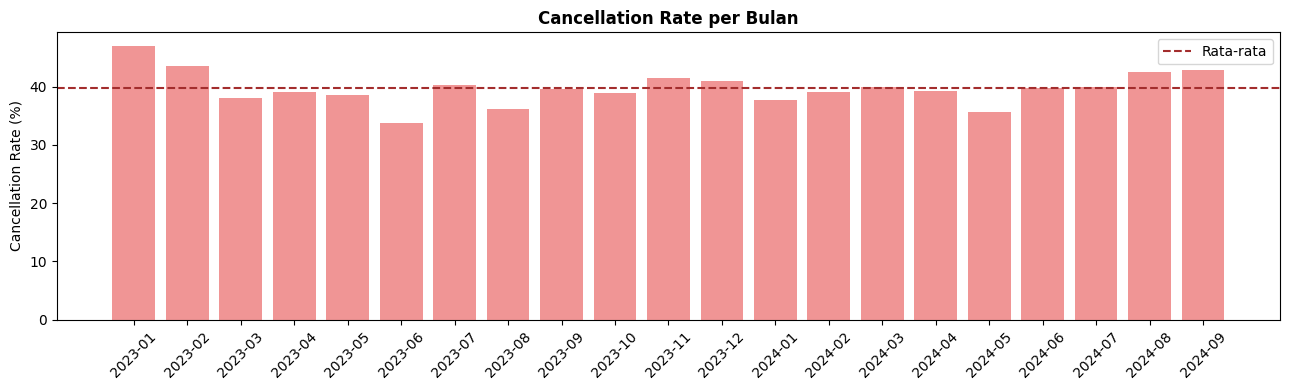

is_cancel
0    5913
1    3895
Name: count, dtype: int64
Cancellation rate: 39.7%
   month_str  total  cancel  cancel_rate
0    2023-01    466     219    46.995708
1    2023-02    427     186    43.559719
2    2023-03    486     185    38.065844
3    2023-04    455     178    39.120879
4    2023-05    451     174    38.580931
5    2023-06    449     152    33.853007
6    2023-07    489     197    40.286299
7    2023-08    458     166    36.244541
8    2023-09    483     191    39.544513
9    2023-10    508     198    38.976378
10   2023-11    466     193    41.416309
11   2023-12    501     205    40.918164
12   2024-01    512     193    37.695312
13   2024-02    443     173    39.051919
14   2024-03    471     188    39.915074
15   2024-04    471     185    39.278132
16   2024-05    484     173    35.743802
17   2024-06    440     175    39.772727
18   2024-07    435     174    40.000000
19   2024-08    479     204    42.588727
20   2024-09    434     186    42.857143


In [43]:
by_month = df.groupby('month').agg(
    total  = ('saleID', 'count'),
    cancel = ('is_cancel', 'sum')
).reset_index()
by_month['cancel_rate'] = by_month['cancel'] / by_month['total'] * 100
by_month['month_str'] = by_month['month'].astype(str)

plt.figure(figsize=(13, 4))
plt.bar(by_month['month_str'], by_month['cancel_rate'], color='#F09595')
plt.axhline(by_month['cancel_rate'].mean(), color='#A32D2D',
            linestyle='--', label='Rata-rata')
plt.title('Cancellation Rate per Bulan', fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('cancellation_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(by_month[['month_str','total','cancel','cancel_rate']].to_string())

**Insight:**  
- Dari plot, semua bulan *cancel rate*-nya berkisar 33–46%, tidak ada bulan yang *cancel rate*-nya rendah secara signifikan. Artinya masalah ini bukan seasonal tapi sistemik, ada sesuatu yang salah di proses bisnis secara keseluruhan.
- Mobile app punya *cancel rate* tertinggi padahal harusnya digital channel lebih mudah diproses. Ini sinyal ada masalah di aplikasinya, mungkin UI membingungkan, proses pembayaran bermasalah, atau ekspektasi produk tidak sesuai foto.

**Rekomendasi:**  
Karena *cancel rate* tinggi merata di semua bulan, channel, dan kategori. Hal ini bukan masalah satu area tapi masalah sistemik. Bisnis perlu investigasi lebih dalam ke kolom status, bedakan mana yang *Cancelled* (dibatalin customer) dan *Returned* (barang dikembalikan) karena penyebab dan solusinya berbeda.



---
---

**4. Customer mana yang berpotensi untuk dipertahankan dan mana yang sudah lama tidak bertransaksi?**  
RFM Analysis --> Tidak semua customer sama nilainya. Bisnis perlu tahu siapa mereka supaya bisa diperlakukan spesial seperti dikasih *loyalty reward, early access* produk baru, dan lain-lain. Sementara customer yang lama tidak balik perlu didekati lagi sebelum benar-benar hilang.

In [44]:
snapshot = df_success['saleDate'].max() + pd.Timedelta(days=1)

rfm = df_success.groupby(['customerID','customerName']).agg(
    recency   = ('saleDate',    lambda x: (snapshot - x.max()).days),
    frequency = ('saleID',      'count'),
    monetary  = ('totalAmount', 'sum')
).reset_index()

print(rfm.describe().round(0))

       recency  frequency  monetary
count   3940.0     3940.0    3940.0
mean     323.0        1.0    2670.0
std      180.0        0.0    2040.0
min        1.0        1.0     200.0
25%      170.0        1.0    1165.0
50%      326.0        1.0    2060.0
75%      477.0        1.0    3740.0
max      639.0        1.0    9999.0


In [45]:
rfm['R'] = pd.qcut(rfm['recency'],
                   5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'),
                   5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'],
                   5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
print(rfm[['customerName','recency','frequency','monetary','R','F','M']].head(10))

   customerName  recency  frequency  monetary  R  F  M
0  Sathish_0001      575          1    247.34  1  1  1
1     Ravi_0006       11          1   1462.12  5  1  2
2     Devi_0010      582          1   2187.92  1  1  3
3   Ganesh_0013      108          1   1593.71  5  1  2
4   Ganesh_0023      532          1    475.69  1  1  1
5    Meena_0027      226          1   2467.00  4  1  4
6     Diya_0028      202          1   8188.88  4  1  5
7     Devi_0030      186          1    476.30  4  1  1
8     Diya_0031      492          1   1114.42  2  1  2
9    Aarav_0032       94          1   2326.80  5  1  3


In [46]:
def segment(row):
    r, f = row['R'], row['F']
    if r >= 4 and f >= 4:   return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'New Customer'
    elif r <= 2 and f >= 3: return 'At Risk'
    else:                   return 'Others'

rfm['segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    jumlah   = ('customerID', 'count'),
    avg_spending = ('monetary', 'mean'),
    total_revenue = ('monetary', 'sum')
).sort_values('total_revenue', ascending=False)

print(seg_summary.round(0))


              jumlah  avg_spending  total_revenue
segment                                          
At Risk          949        2716.0      2577453.0
Others           926        2590.0      2398760.0
Loyal            806        2675.0      2156234.0
New Customer     650        2791.0      1813898.0
Champions        609        2582.0      1572140.0


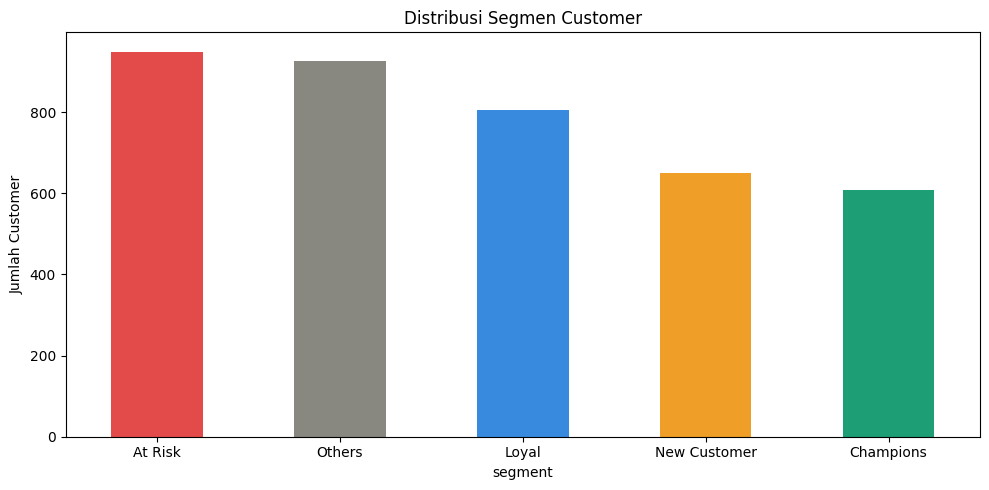


=== TOP CHAMPIONS ===
      customerName  monetary  frequency
3606     Ravi_9162   9877.72          1
3810  Bhuvana_9675   9711.40          1
2599  Lakshmi_6666   9442.60          1
3551    Aarav_9025   9372.48          1
3091    Priya_7839   9121.36          1
2882     Diya_7339   8997.24          1
2592    Aarav_6644   8863.12          1
3637    Priya_9228   8844.64          1
2679    Kavin_6868   8775.80          1
2848  Bhuvana_7247   8727.84          1

=== AT RISK ===
      customerName  recency  monetary
3454    Meena_8781      639   1369.96
3835    Kavin_9745      638   1204.08
3855    Aarav_9786      638   1148.12
2318     Devi_5963      637   5767.38
3840   Vishal_9755      637   2346.90
1664     Diya_4287      637   1028.30
2886    Aarav_7348      637   1018.62
2630  Karthik_6741      637   4051.77
2756     Devi_7030      637    538.64
2052   Sanjay_5326      637   3867.00


In [47]:
# Bar chart segmen
colors_map = {'Champions':'#1D9E75','Loyal':'#378ADD',
              'New Customer':'#EF9F27','At Risk':'#E24B4A','Others':'#888780'}
seg_summary['color'] = [colors_map[s] for s in seg_summary.index]

seg_summary['jumlah'].plot(kind='bar', color=seg_summary['color'],
                            figsize=(10,5), title='Distribusi Segmen Customer')
plt.ylabel('Jumlah Customer')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rfm_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# Export daftar per segmen
print("\n=== TOP CHAMPIONS ===")
print(rfm[rfm['segment']=='Champions'][['customerName','monetary','frequency']].sort_values('monetary',ascending=False).head(10).to_string())
print("\n=== AT RISK ===")
print(rfm[rfm['segment']=='At Risk'][['customerName','recency','monetary']].sort_values('recency',ascending=False).head(10).to_string())

rfm.to_csv('rfm_result.csv', index=False)

**Insight:**  
Dari hasil RFM analysis, bisnis memiliki 609 Champions dengan top spender Ravi_9162 (Rp 9,877) dan Bhuvana_9675 (Rp 9,711) yang perlu diberikan treatment spesial seperti loyalty reward dan early access produk baru untuk mempertahankan mereka. Di sisi lain, segmen At Risk justru menjadi yang terbesar dengan 949 customer, dimana beberapa diantaranya sudah tidak melakukan transaksi hingga 639 hari seperti Meena_8781 dan Kavin_9745.

**Rekomendasi:**  
- Bisnis perlu segera melakukan win-back campaign dengan promo khusus, terutama menyasar customer yang recency-nya masih di kisaran 300–400 hari karena masih lebih berpeluang untuk kembali dibanding yang sudah 600+ hari tidak beli.  
- Masalah utamanya bukan di segmentasi customer, tapi di tidak adanya repeat purchase sama sekali. Rekomendasi terpenting: implementasikan program loyalitas, follow-up email setelah pembelian pertama, dan membership program untuk dorong customer beli kedua kali.